In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Mean, Median, or Mode Imputation (Univariate Imputation)

## A) Mean imputation

In [ ]:
#SKIP (First lets generate data) Set random seed for reproducibility
np.random.seed(42)

# # Step 1: Create a DataFrame with 60 patients and normally distributed blood pressure readings
# data = {
#     'Patient_ID': [f'P{i+1:03d}' for i in range(60)],
#     'BP': np.random.normal(loc=120, scale=10, size=60)  # mean=120, std=10
# }

# df = pd.DataFrame(data)

# # Step 2: Randomly insert missing values (about 20% of them)
# missing_indices = np.random.choice(df.index, size=12, replace=False)
# df.loc[missing_indices, 'BP'] = np.nan
# df.to_csv('missing_patient_BP.csv', index=False)
###################################################################


In [3]:
# 1) read the data and print

df = pd.read_csv('missing_patient_BP.csv')
print(df)

   Patient_ID          BP
0        P001  124.967141
1        P002  118.617357
2        P003  126.476885
3        P004  135.230299
4        P005  117.658466
5        P006         NaN
6        P007  135.792128
7        P008         NaN
8        P009  115.305256
9        P010  125.425600
10       P011  115.365823
11       P012         NaN
12       P013  122.419623
13       P014  100.867198
14       P015  102.750822
15       P016         NaN
16       P017  109.871689
17       P018         NaN
18       P019  110.919759
19       P020  105.876963
20       P021         NaN
21       P022  117.742237
22       P023  120.675282
23       P024  105.752518
24       P025  114.556173
25       P026  121.109226
26       P027  108.490064
27       P028         NaN
28       P029         NaN
29       P030  117.083062
30       P031  113.982934
31       P032  138.522782
32       P033  119.865028
33       P034  109.422891
34       P035  128.225449
35       P036  107.791563
36       P037  122.088636
37       P03

# Display missing values for each column

In [4]:
missing_values = df.isnull().sum()

print("\nMissing Values:\n", missing_values )


Missing Values:
 Patient_ID     0
BP            12
dtype: int64


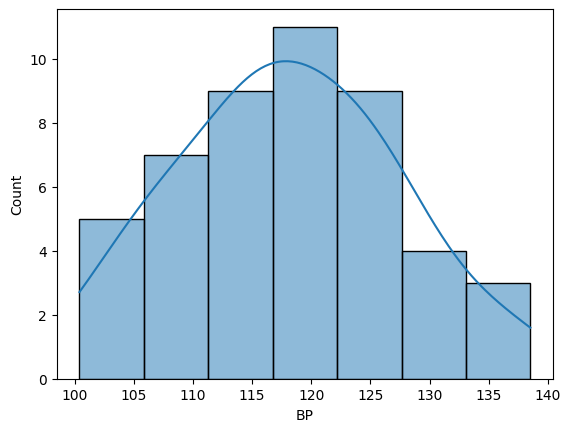

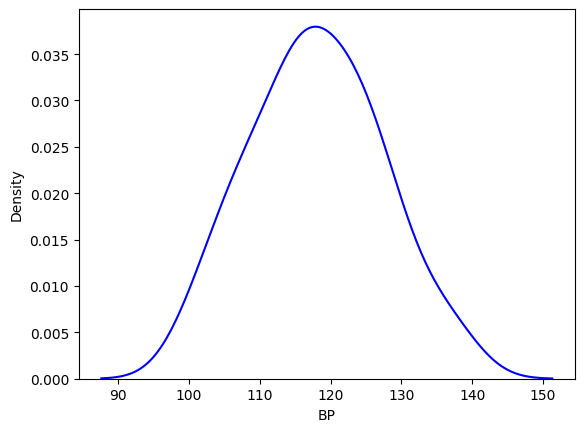

In [5]:
# 2) Lets plot the blood pressure and verify that it has normal distribution
x = df['BP']

sns.histplot(x, kde=True)
plt.show()

# KDE Plot 
sns.kdeplot(x, color='blue', label='Original (with NaN)')

plt.show()

### obseravtion:
- the Blood Pressure has normal distribution curve. So we can fill the mising value with **mean value.**

In [8]:
# 3) 
mean_bp = df['BP'].mean()
mean_bp = np.round(mean_bp,2)
print("\nMean Blood Pressure before imputation (ignoring NaN):", mean_bp)

df['BP_Imputed'] = df['BP'].fillna(mean_bp)

print("\nData after Mean Imputation:\n", df)


Mean Blood Pressure before imputation (ignoring NaN): 118.0

Data after Mean Imputation:
    Patient_ID          BP  BP_Imputed
0        P001  124.967141  124.967141
1        P002  118.617357  118.617357
2        P003  126.476885  126.476885
3        P004  135.230299  135.230299
4        P005  117.658466  117.658466
5        P006         NaN  118.000000
6        P007  135.792128  135.792128
7        P008         NaN  118.000000
8        P009  115.305256  115.305256
9        P010  125.425600  125.425600
10       P011  115.365823  115.365823
11       P012         NaN  118.000000
12       P013  122.419623  122.419623
13       P014  100.867198  100.867198
14       P015  102.750822  102.750822
15       P016         NaN  118.000000
16       P017  109.871689  109.871689
17       P018         NaN  118.000000
18       P019  110.919759  110.919759
19       P020  105.876963  105.876963
20       P021         NaN  118.000000
21       P022  117.742237  117.742237
22       P023  120.675282  120.6752

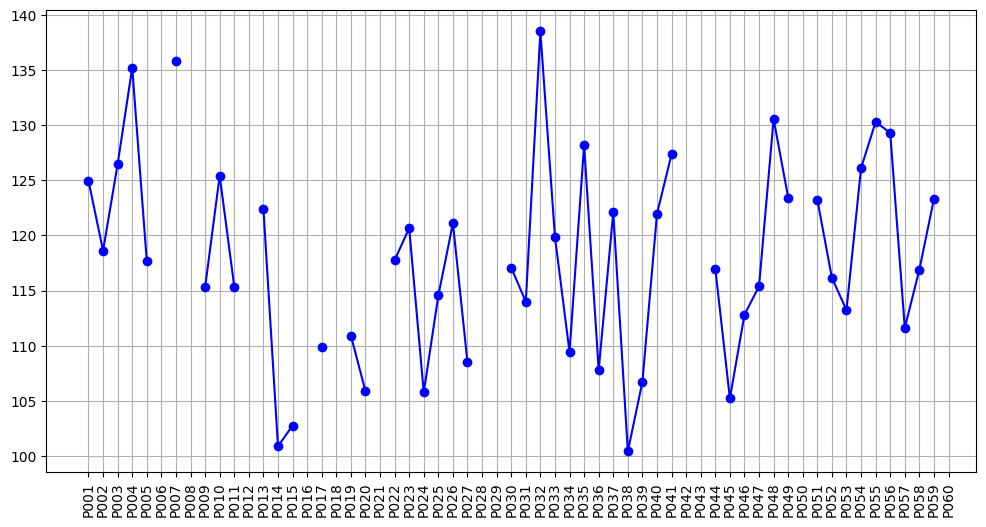

In [9]:
# 4) Visualize the original missing column
x          = df['Patient_ID']
bp         = df['BP']
plt.figure(figsize=(12, 6))
plt.plot(x, bp,          label='Original', marker='o', linestyle='-', color='blue')   # with missing

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

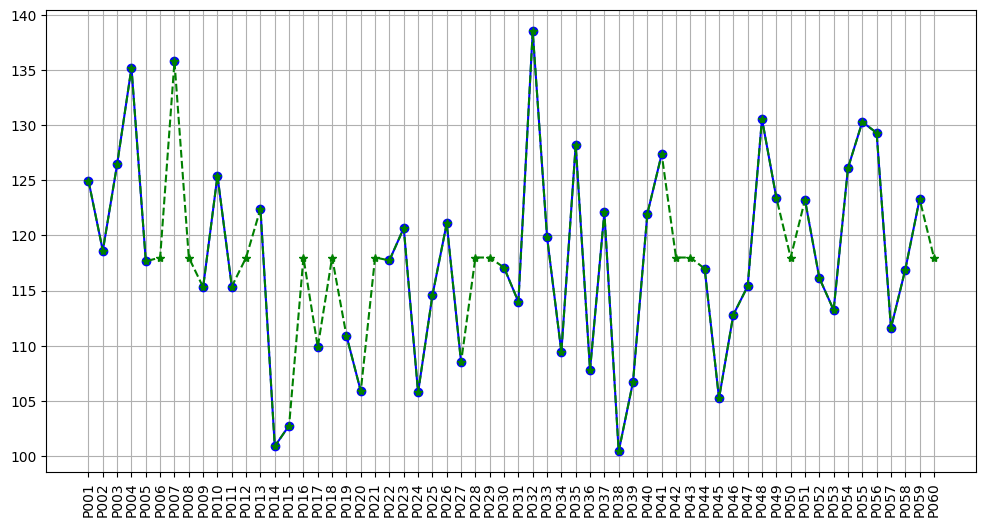

In [10]:
# 4) Visualize the difference between missing column and imputed column
x          = df['Patient_ID']
bp         = df['BP']
bp_imputed = df['BP_Imputed']


plt.figure(figsize=(12, 6))
plt.plot(x, bp,          label='Original', marker='o', linestyle='-', color='blue')   # with missing
plt.plot(x, bp_imputed , label='Imputed',  marker='*', linestyle='--', color='green') # without missing

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

#### observation:
- the missing values for patient p006, p008,p012, etc are all imputed with same number, mean = 118

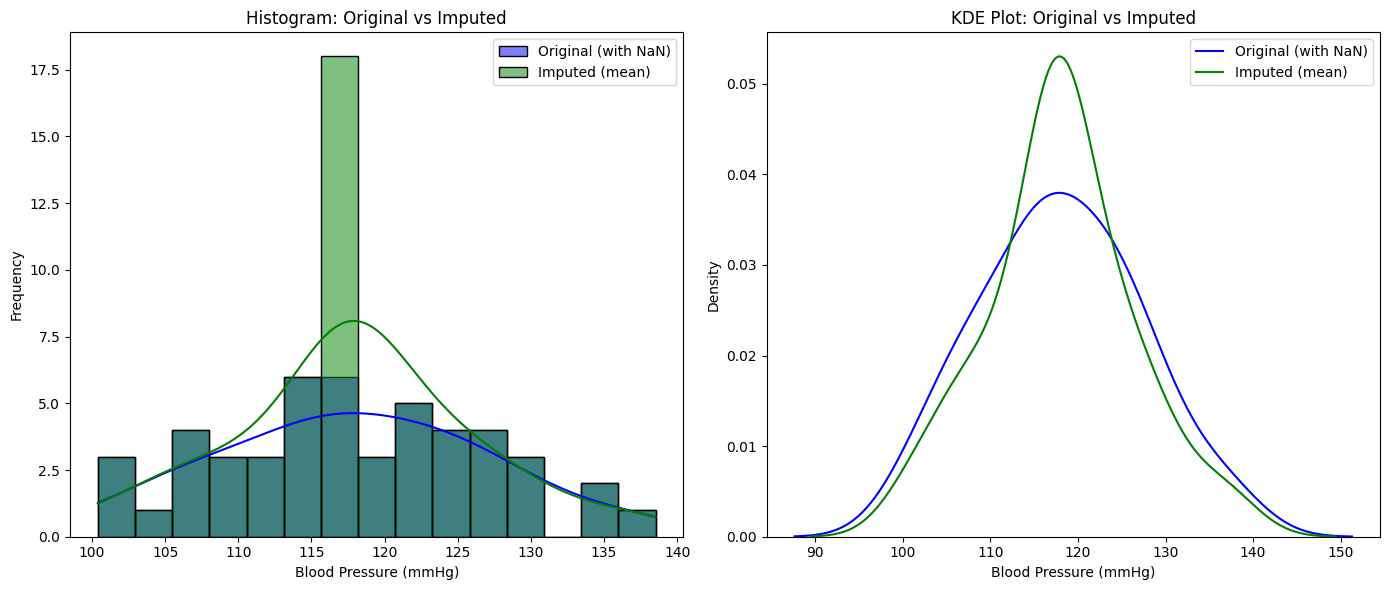


 Descriptive Statistics:
Original (ignoring NaN):
count     48.000000
mean     117.998387
std        9.246372
min      100.403299
25%      111.435808
50%      117.370764
75%      123.818923
max      138.522782
Name: BP, dtype: float64

After Imputation (mean):
count     60.000000
mean     117.998710
std        8.252666
min      100.403299
25%      113.794895
50%      118.000000
75%      122.624927
max      138.522782
Name: BP_Imputed, dtype: float64


In [11]:
# 5)
# Create copies to compare
original = df['BP']
imputed = df['BP_Imputed']

# Set up the plot
plt.figure(figsize=(14, 6))

# Histogram comparison
plt.subplot(1, 2, 1)
sns.histplot(original, kde=True, bins=15, color='blue', label='Original (with NaN)')
sns.histplot(imputed, kde=True, bins=15, color='green', label='Imputed (mean)', alpha=0.5)
plt.title("Histogram: Original vs Imputed")
plt.xlabel("Blood Pressure (mmHg)")
plt.ylabel("Frequency")
plt.legend()

# KDE Plot comparison
plt.subplot(1, 2, 2)
sns.kdeplot(original, color='blue', label='Original (with NaN)')
sns.kdeplot(imputed, color='green', label='Imputed (mean)')
plt.title("KDE Plot: Original vs Imputed")
plt.xlabel("Blood Pressure (mmHg)")
plt.legend()

plt.tight_layout()
plt.show()

# Descriptive statistics
print("\n Descriptive Statistics:")
print("Original (ignoring NaN):")
print(original.describe())
print("\nAfter Imputation (mean):")
print(imputed.describe())


#### observation
what are you looking for ?

- The KDE plots should look very similar since mean imputation doesn’t distort the shape much: **Thats true here**
- The histogram will show some stacked bars at the imputed mean value: **Thats true here as you can see tall bar at 118**
- The mean will be the same, but the std might slightly reduce due to flattening of the variance: **The mean is same in both, and std_dev went down from 9.2 to 8.2**

## B) Median imputation

In [ ]:
# (SKIP)
np.random.seed(42) # Set seed for reproducibility

# # Step 1: Generate skewed data (using exponential distribution)
# visits = np.random.exponential(scale=3, size=60).round()

# # Step 2: Introduce missing values in about 15% of records
# mask = np.random.choice([True, False], size=60, p=[0.15, 0.85])
# visits[mask] = np.nan

# # Step 3: Create DataFrame
# # This is the number of monthly doctor visits by patients in a clinic. Some patients didn’t 
# # report their number of visits. The data is skewed because a few patients visit
# # the doctor very frequently (outliers).
# df = pd.DataFrame({'Monthly_Doctor_Visits': visits})
# df.to_csv('missing_monthly_dr_visits.csv', index=False)

In [15]:
# 1) 
df = pd.read_csv('missing_monthly_dr_visits.csv')

print(f"First 20 records: \n{df.head(20)}")

First 20 records: 
    Monthly_Doctor_Visits
0                     1.0
1                     9.0
2                     4.0
3                     3.0
4                     1.0
5                     1.0
6                     NaN
7                     6.0
8                     NaN
9                     4.0
10                    0.0
11                   11.0
12                    NaN
13                    1.0
14                    1.0
15                    1.0
16                    1.0
17                    NaN
18                    2.0
19                    NaN


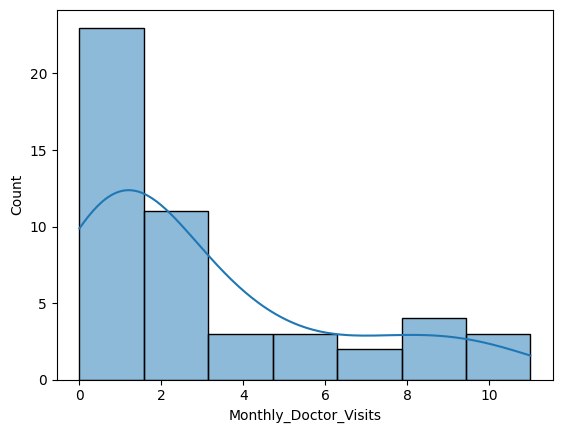

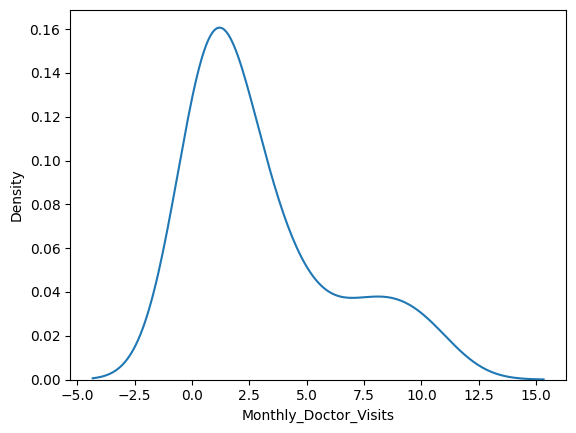

In [16]:
# 2) Plot the curve

x = df['Monthly_Doctor_Visits']

sns.histplot(x, kde=True)
plt.show()

# KDE
sns.kdeplot(x)
plt.show()

## observation
- distribution is not normal. It is skewed to the right

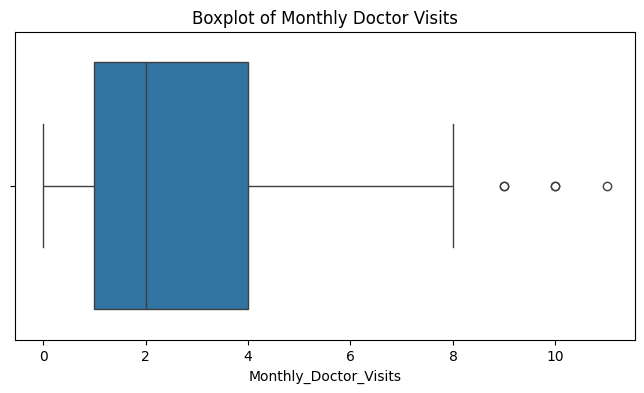

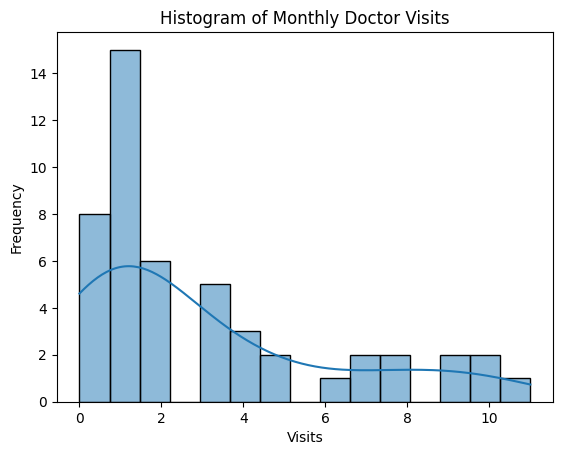

Outliers based on IQR:
     Monthly_Doctor_Visits
1                     9.0
11                   11.0
33                    9.0
34                   10.0
50                   10.0


In [17]:
# 3) 

# Lets check if there are any outliers ?

# method1
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Monthly_Doctor_Visits'])
plt.title("Boxplot of Monthly Doctor Visits")
plt.show()

# method2: Histogram with KDE (To See Skew + Spread)
sns.histplot(df['Monthly_Doctor_Visits'], bins=15, kde=True)
plt.title("Histogram of Monthly Doctor Visits")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

# method3: IQR Method (Interquartile Range)
Q1 = df['Monthly_Doctor_Visits'].quantile(0.25)
Q3 = df['Monthly_Doctor_Visits'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Monthly_Doctor_Visits'] < lower_bound) | (df['Monthly_Doctor_Visits'] > upper_bound)]
print("Outliers based on IQR:\n", outliers)


### observation
- From box-plot and IQR method we see there are total of 5 outliers with 3 outliers values: 9, 10 and 11.
- we see the presence of outliers and the dist curve is skewed to the right. So we impute with median

In [19]:
# 4) Impute with median

median_value = df['Monthly_Doctor_Visits'].median()
print("median:", median_value)

df['Visits_Imputed'] = df['Monthly_Doctor_Visits'].fillna(median_value)

print(df)

median: 2.0
    Monthly_Doctor_Visits  Visits_Imputed
0                     1.0             1.0
1                     9.0             9.0
2                     4.0             4.0
3                     3.0             3.0
4                     1.0             1.0
5                     1.0             1.0
6                     NaN             2.0
7                     6.0             6.0
8                     NaN             2.0
9                     4.0             4.0
10                    0.0             0.0
11                   11.0            11.0
12                    NaN             2.0
13                    1.0             1.0
14                    1.0             1.0
15                    1.0             1.0
16                    1.0             1.0
17                    NaN             2.0
18                    2.0             2.0
19                    NaN             2.0
20                    3.0             3.0
21                    0.0             0.0
22                    

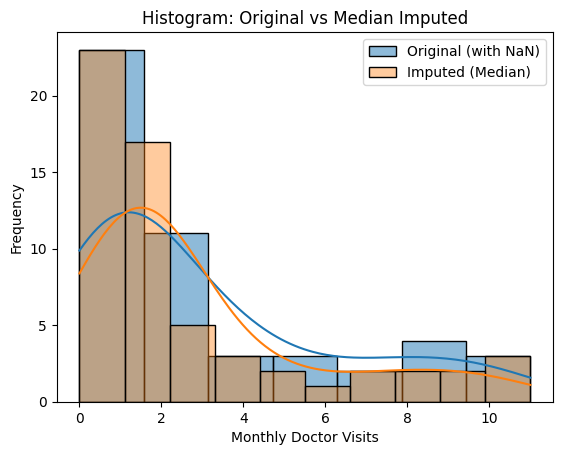

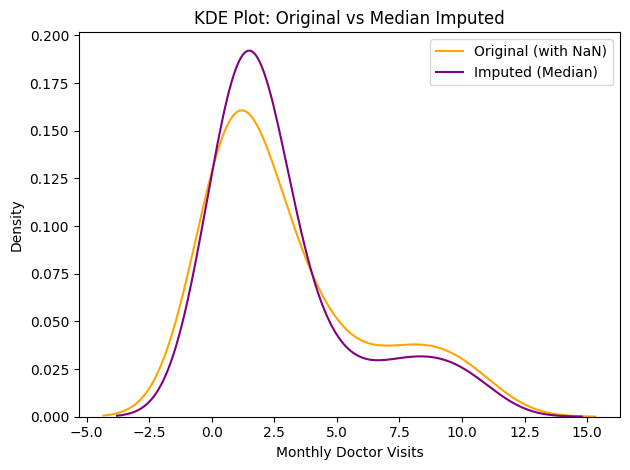


 Descriptive Statistics:
Original (excluding NaNs):
count    49.000000
mean      3.040816
std       3.142181
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      11.000000
Name: Monthly_Doctor_Visits, dtype: float64

After Median Imputation:
count    60.00000
mean      2.85000
std       2.86312
min       0.00000
25%       1.00000
50%       2.00000
75%       3.25000
max      11.00000
Name: Visits_Imputed, dtype: float64


In [20]:

sns.histplot(df['Monthly_Doctor_Visits'], kde=True, label='Original (with NaN)')
sns.histplot(df['Visits_Imputed'], kde=True, label='Imputed (Median)', alpha=0.4)

plt.title("Histogram: Original vs Median Imputed")
plt.xlabel("Monthly Doctor Visits")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# KDE
sns.kdeplot(df['Monthly_Doctor_Visits'], label='Original (with NaN)', color='orange')
sns.kdeplot(df['Visits_Imputed'], label='Imputed (Median)', color='purple')
plt.title("KDE Plot: Original vs Median Imputed")
plt.xlabel("Monthly Doctor Visits")
plt.legend()
plt.tight_layout()

plt.show()

# Step 6: Descriptive statistics
print("\n Descriptive Statistics:")
print("Original (excluding NaNs):")
print(df['Monthly_Doctor_Visits'].describe())
print("\nAfter Median Imputation:")
print(df['Visits_Imputed'].describe())

#### observation
- After imputation, the shape stays true to original, with less distortion (than if you used mean.)

## C) Mode

In [ ]:
# (SKIP) first we generate the data:
# Set seed for reproducibility
# np.random.seed(42)

# # Step 1: Create list of learning methods
# methods = ['Visual', 'Auditory', 'Kinesthetic', 'Reading/Writing']
# methods = ['Visual', 'Auditory', 'Kinesthetic', 'Reading/Writing']
# probs = [0.4, 0.3, 0.2, 0.1]  # Visual is most common

# # Generate 60 random learning preferences
# learning_prefs = np.random.choice(methods, size=60, p=probs)

# # Step 2: Introduce missing values (~20%)
# mask = np.random.choice([True, False], size=60, p=[0.2, 0.8])
# learning_prefs[mask] = np.nan

# # Step 3: Create DataFrame
# df = pd.DataFrame({'Preferred_Learning_Method': learning_prefs})
# df['Preferred_Learning_Method'] = df['Preferred_Learning_Method'].replace('nan', np.nan) # for some reason, 'nan' was string
# df.to_csv('missing_learning_method.csv', index=False)


In [21]:
# 1) Read df
df = pd.read_csv('missing_learning_method.csv')

print(f"Before imputation: \n{df}")

Before imputation: 
   Preferred_Learning_Method
0                     Visual
1            Reading/Writing
2                Kinesthetic
3                   Auditory
4                     Visual
5                     Visual
6                        NaN
7                Kinesthetic
8                        NaN
9                Kinesthetic
10                    Visual
11                       NaN
12                       NaN
13                    Visual
14                    Visual
15                    Visual
16                    Visual
17                       NaN
18                  Auditory
19                       NaN
20                  Auditory
21                    Visual
22                    Visual
23                       NaN
24                  Auditory
25               Kinesthetic
26                    Visual
27                  Auditory
28                  Auditory
29                    Visual
30                       NaN
31                    Visual
32                    V

In [22]:
# 2) Impute with mode: most frequent value

mode_value = df['Preferred_Learning_Method'].mode()[0]
print("mode:", mode_value)

mode: Visual


In [23]:

df['Method_Imputed'] = df['Preferred_Learning_Method'].fillna(mode_value)

print(f"After imputation: \n{df}")

After imputation: 
   Preferred_Learning_Method   Method_Imputed
0                     Visual           Visual
1            Reading/Writing  Reading/Writing
2                Kinesthetic      Kinesthetic
3                   Auditory         Auditory
4                     Visual           Visual
5                     Visual           Visual
6                        NaN           Visual
7                Kinesthetic      Kinesthetic
8                        NaN           Visual
9                Kinesthetic      Kinesthetic
10                    Visual           Visual
11                       NaN           Visual
12                       NaN           Visual
13                    Visual           Visual
14                    Visual           Visual
15                    Visual           Visual
16                    Visual           Visual
17                       NaN           Visual
18                  Auditory         Auditory
19                       NaN           Visual
20             

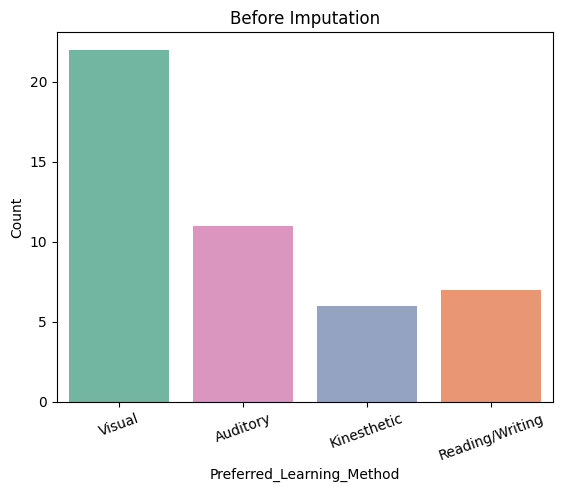

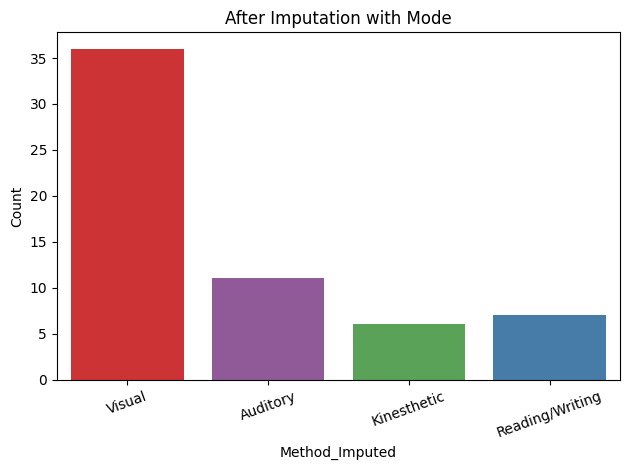


Frequency Counts:
Before (excluding NaNs):
Preferred_Learning_Method
Visual             22
Auditory           11
Reading/Writing     7
Kinesthetic         6
Name: count, dtype: int64

After Mode Imputation:
Method_Imputed
Visual             36
Auditory           11
Reading/Writing     7
Kinesthetic         6
Name: count, dtype: int64


In [24]:
# 3)

methods = ['Visual', 'Auditory', 'Kinesthetic', 'Reading/Writing']

# Before imputation
# sns.countplot(x='Preferred_Learning_Method', data=df, order=methods, palette='Set2')
sns.countplot(x='Preferred_Learning_Method', data=df, order=methods, hue='Preferred_Learning_Method', palette='Set2', legend=False)

plt.title("Before Imputation")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# After imputation
# sns.countplot(x='Method_Imputed', data=df, order=methods, palette='Set1')
sns.countplot(x='Method_Imputed', data=df, order=methods, hue='Method_Imputed', palette='Set1', legend=False)

plt.title("After Imputation with Mode")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#  Frequency before and after
print("\nFrequency Counts:")
print("Before (excluding NaNs):")
print(df['Preferred_Learning_Method'].value_counts(dropna=True))
print("\nAfter Mode Imputation:")
print(df['Method_Imputed'].value_counts())


### observaion
Left Plot – Before Imputation:
- This shows the distribution of non-missing learning preferences.
- You can spot that one category—probably 'Visual'—has a clear lead in frequency. This tells you that 'Visual' is the mode.

Right Plot – After Imputation:
- This includes both original and filled values.
- The bar for the mode category (e.g., 'Visual') increases compared to the original. Other categories should remain unchanged.
- The overall distribution shape is preserved, just slightly skewed toward the mode.

**Why That Confirms Mode Was a Good Choice:**
- The mode already dominated the data, so reinforcing that pattern doesn't introduce bias.
- You are not distorting the categorical distribution.
- If you had chosen something else (like random fill), the distribution would become noisier and less realistic.
- **If the categories were all evenly distributed, mode might not be ideal—but here it's clearly skewed to one.**